#  PROJECT OVERVIEW

### Business Context
This dataset contains all transactions from a UK-based non-store online retailer
between December 2009 and December 2011. The company sells unique all-occasion
gift-ware, with a significant portion of its customer base being wholesalers.

The goal of this analysis is to surface actionable insights around revenue
performance, customer behavior, and product demand to inform the company's
growth and retention strategy.

### Key Questions
1. How does revenue trend over time — are there seasonal patterns or growth periods?
2. Which countries drive the most revenue outside the UK?
3. Which products are the top and bottom performers by revenue and volume?
4. What does customer purchasing behavior look like — frequency, order size, repeat buyers?
5. Are there anomalies in the data (cancellations, returns, negative quantities)
   that affect reported revenue?


In [22]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Loading Data

In [23]:
# Loading Data

DATA_PATH = Path("../data/raw/online_retail.xlsx")

df_2009 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")

raw_data = pd.concat([df_2009, df_2010], ignore_index=True)

df = raw_data.copy()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [24]:
# General Inspection

print('*** General info ***\n')
df.info()
print("\nShape:", df.shape)
print('\nColumn names:', df.columns)

*** General info ***

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB

Shape: (1067371, 8)

Column names: Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')


In [25]:
# Unique value counts per column
for col in df.columns:
    print(f"{col}: {df[col].nunique():,} unique values")

Invoice: 53,628 unique values
StockCode: 5,305 unique values
Description: 5,698 unique values
Quantity: 1,057 unique values
InvoiceDate: 47,635 unique values
Price: 2,807 unique values
Customer ID: 5,942 unique values
Country: 43 unique values


In [26]:
# Checking For Missing Data

print('\n*** Missing values ***\n')
print(df.isna().sum())

# Checking For Duplicate Rows

duplicates = df.duplicated().sum()
print('\n*** Duplicated Rows ***\n\nAmount:', duplicates)



*** Missing values ***

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

*** Duplicated Rows ***

Amount: 34335


In [27]:
# Dropping Missing Values And Duplicates
# Keeping CustomerID Missing Values, Column Not Needed For Analysis But Rows Are Important
df.dropna(subset=['Description'], inplace=True)
df.drop_duplicates(inplace=True)

print(f'Shape After Cleaning: {df.shape}')

Shape After Cleaning: (1028761, 8)


## Preprocessing

In [28]:
# Standardizing Column Names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^0-9a-zA-Z]+', '_', regex=True)
    .str.strip('_')
)
df.columns.tolist()


['invoice',
 'stockcode',
 'description',
 'quantity',
 'invoicedate',
 'price',
 'customer_id',
 'country']

In [29]:
# Normalization (Min-Max Scaling)
def minmax(series):
    series = pd.to_numeric(series, errors='coerce')
    min, max = series.min(), series.max()
    return (series - min) / (max - min)


df['norm_price'] = minmax(df['price'])
df['norm_quantity'] = minmax(df['quantity'])

print(df[['price', 'norm_price', 'quantity', 'norm_quantity']].head())

# This helps compare metrics like price and quantity on a common scale without changing their relationships.

   price  norm_price  quantity  norm_quantity
0   6.95    0.579071        12       0.500074
1   6.75    0.579069        12       0.500074
2   6.75    0.579069        12       0.500074
3   2.10    0.579018        48       0.500296
4   1.25    0.579009        24       0.500148


## Task 2: Data Analysis

In [30]:
# Using SciPy For More Statisitical Evaluation
mean_sales = stats.tmean(df['price'])
median_sales = stats.scoreatpercentile(df['price'], 50)
std_sales = stats.tstd(df['price'])

mean_unit = stats.tmean(df['quantity'])
median_unit = stats.scoreatpercentile(df['quantity'], 50)
std_unit = stats.tstd(df['quantity'])

print('*** Sales ***\n')
print(f'Mean: {mean_sales:.2f}, Median: {median_sales:.2f}, Std: {std_sales:.2f}')
print('\n*** Units ***\n')
print(f'Mean: {mean_unit:.2f}, Median: {median_unit:.2f}, Std: {std_unit:.2f}')

*** Sales ***

Mean: 4.63, Median: 2.10, Std: 122.65

*** Units ***

Mean: 10.19, Median: 3.00, Std: 172.37


In [56]:
# Best and Worst Performing Countries

by_country = df.groupby('country')['quantity'].sum().sort_values(ascending=False)
print('Highest Volume Group:', by_country.index[0])
print('\nLowest Volume Group:', by_country.index[-1])

by_country

Highest Volume Group: United Kingdom

Lowest Volume Group: Nigeria


country
United Kingdom          8587949
Netherlands              381853
EIRE                     327431
Denmark                  234764
Germany                  221816
France                   181572
Australia                103375
Sweden                    87858
Switzerland               52256
Spain                     44667
Belgium                   34598
Japan                     30138
Portugal                  27368
Norway                    23528
Channel Islands           20387
Italy                     15122
Finland                   14317
Austria                   11306
Cyprus                    10652
Greece                     7707
Hong Kong                  7015
Singapore                  6987
United Arab Emirates       6728
Unspecified                6711
Poland                     5504
Israel                     5482
USA                        3700
Canada                     3657
Iceland                    2967
Bermuda                    2798
Thailand                   2552


In [52]:
# Customer Group Sales
by_price = df.groupby('country')['norm_price'].sum().sort_values(ascending=False)
print('Highest Revenue Group:', by_price.index[0])
print('Lowest Revenue Group:', by_price.index[-1])

by_price

Highest Revenue Group: United Kingdom
Lowest Revenue Group: Saudi Arabia


country
United Kingdom          546644.549689
EIRE                     10230.459315
Germany                  10039.923578
France                    8121.128959
Netherlands               2974.469570
Spain                     2173.769690
Switzerland               1838.440511
Belgium                   1800.835503
Portugal                  1463.881986
Australia                 1094.388261
Channel Islands            953.122898
Italy                      872.636846
Sweden                     788.686101
Norway                     757.768043
Cyprus                     669.965681
Finland                    607.422968
Austria                    543.143106
Denmark                    461.484418
Unspecified                435.441541
Greece                     383.902200
Japan                      327.145788
USA                        309.781632
Poland                     305.151453
United Arab Emirates       289.525391
Israel                     213.084627
Hong Kong                  208.664646
Sing

In [44]:
# The Time Of Day Most Sales Occurred

by_time = df.groupby('invoicedate')['quantity'].sum().sort_values(ascending=False)
print('Most Sales:', by_time.index[0])
print('Least Sales:', by_time.index[-1])

by_time

Most Sales: 2010-08-09 13:10:00
Least Sales: 2010-09-28 11:02:00


invoicedate
2010-08-09 13:10:00    87167
2010-09-27 16:30:00    87166
2010-02-15 11:57:00    83774
2011-12-09 09:15:00    80995
2011-01-18 10:01:00    74215
                       ...  
2010-07-12 15:47:00   -12000
2011-06-14 10:37:00   -19200
2011-01-18 10:17:00   -74215
2011-12-09 09:27:00   -80995
2010-09-28 11:02:00   -87167
Name: quantity, Length: 45111, dtype: int64

In [53]:
# How Sales Change Over Time - Weekly, Monthly, Quarterly Summaries

if 'invoicedate' in df.columns:
    df = df.set_index('invoicedate').sort_index()
    daily = df.resample('D')[['quantity', 'price']].sum()
    weekly = df.resample('W-SUN')[['quantity', 'price']].sum()
    monthly = df.resample('ME')[['quantity', 'price']].sum()
    quarterly = df.resample('QE')[['quantity', 'price']].sum()

    print("Weekly:")
    print(weekly.head())
    print("\nMonthly:")
    print(monthly.head())
    print("\nQuarterly:")
    print(quarterly.head())
    

## Task 3: Visualization

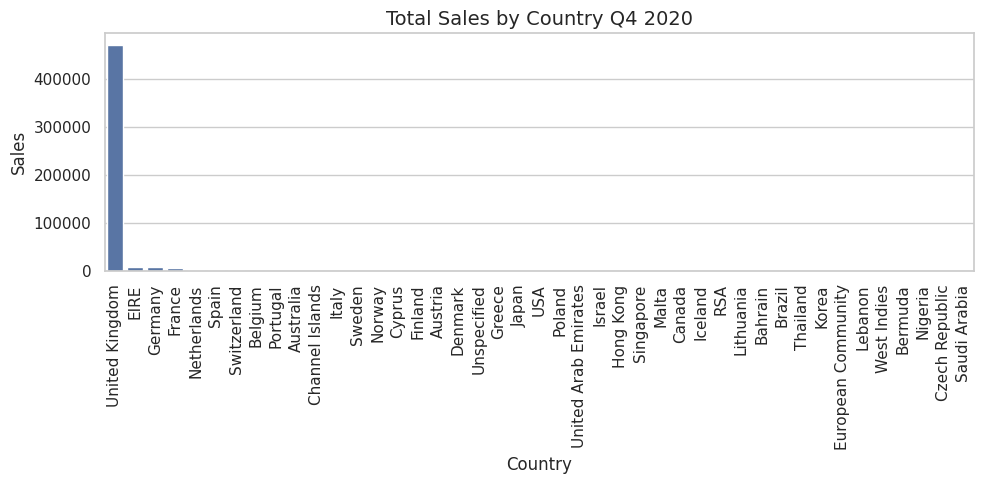

In [54]:
# Bar chart: Sales By Country
sns.barplot(x=by_country.index, y=by_country.values)
plt.title('Total Sales by Country Q4 2020')
plt.xlabel('Country')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_country.png",
            dpi=150, bbox_inches='tight')
plt.show()

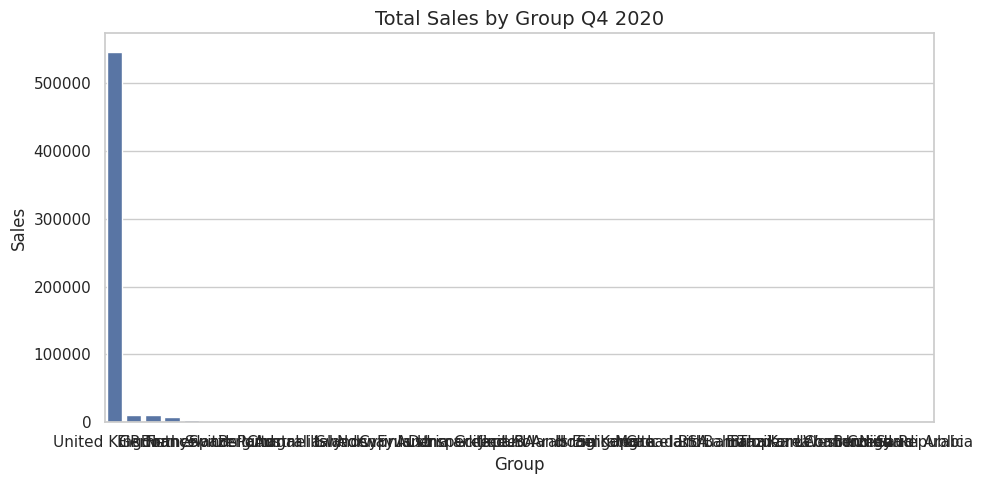

In [55]:
# Bar Chart: Sales by Group

sns.barplot(x=by_price.index, y=by_price.values)
plt.title('Total Sales by Group Q4 2020')
plt.xlabel('Group')
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_group.png",
            dpi=150, bbox_inches='tight')
plt.show()

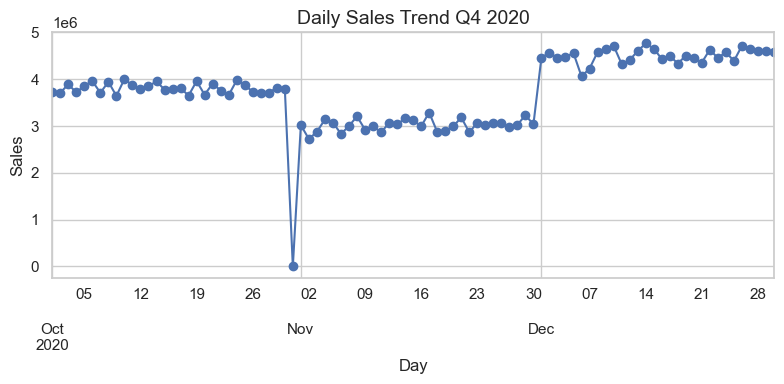

In [ ]:
# Line Plot: Daily Sales Trend

if 'daily' in locals():
    daily['sales'].plot(marker='o')
    plt.title("Daily Sales Trend Q4 2020")
    plt.xlabel("Day")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.savefig("../outputs/figures/daily_sales_trend.png",
                dpi=150, bbox_inches='tight')
    plt.show()

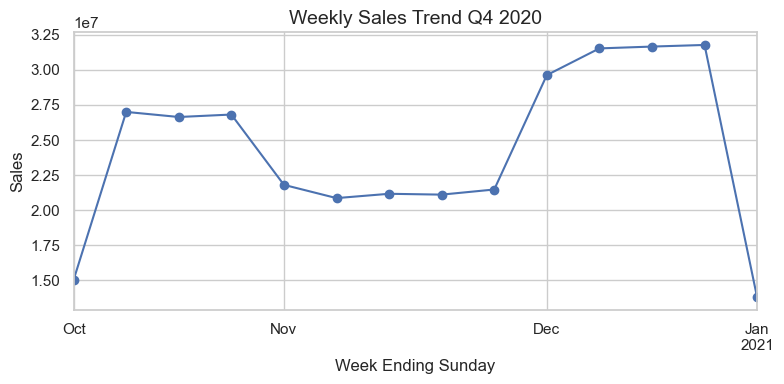

In [ ]:
# Line Plot: Weekly Sales Trend

if 'weekly' in locals():
    weekly['sales'].plot(marker='o')
    plt.title("Weekly Sales Trend Q4 2020")
    plt.xlabel("Week Ending Sunday")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.savefig("../outputs/figures/weekly_sales_trend.png",
                dpi=150, bbox_inches='tight')
    plt.show()

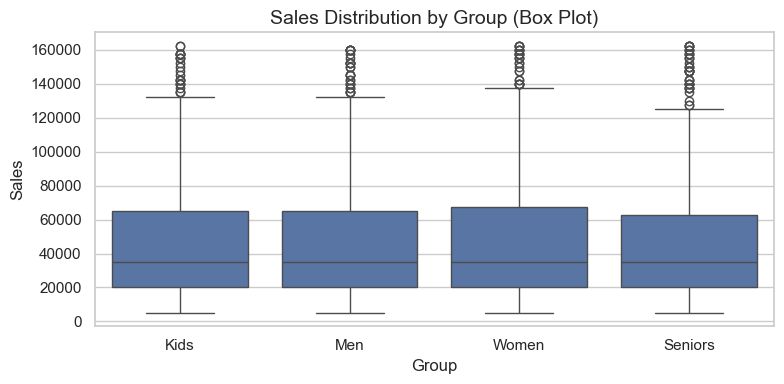

In [ ]:
# Box Plot: Sales by Group
sns.boxplot(x='group', y='sales', data=df.reset_index(drop=True))
plt.title("Sales Distribution by Group (Box Plot)")
plt.xlabel('Group')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig("../outputs/figures/sales_distribution_boxplot.png",
            dpi=150, bbox_inches='tight')
plt.show()

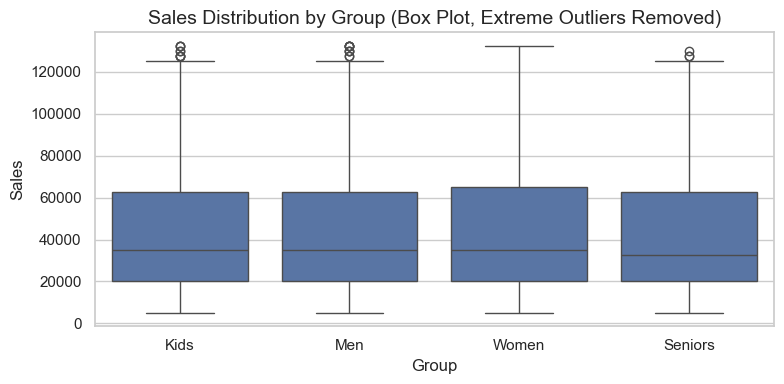

In [ ]:
# Box Plot Of Sales by Group With Outliers Removed
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter
filtered_df = df[(df['sales'] >= lower_bound) & (df['sales'] <= upper_bound)]

# Box Plot Without Extreme Outliers
sns.boxplot(x='group', y='sales', data=filtered_df.reset_index(drop=True))
plt.title("Sales Distribution by Group (Box Plot, Extreme Outliers Removed)")
plt.xlabel("Group")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("../outputs/figures/sales_outlier_distribution_boxplot.png",
            dpi=150, bbox_inches='tight')
plt.show()

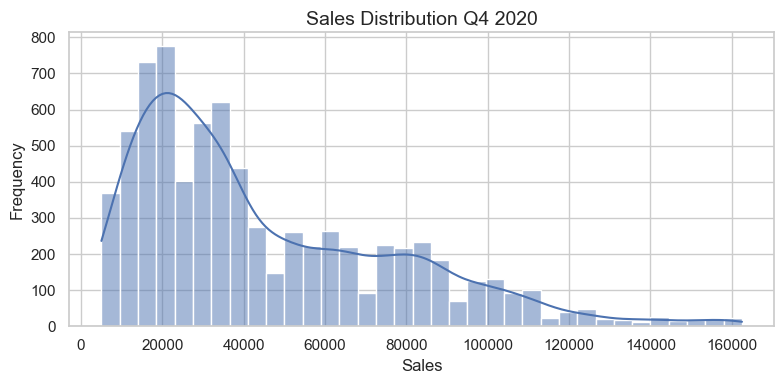

In [ ]:
# Histogram: Sales Distribution
sns.histplot(df['sales'], kde=True)
plt.title('Sales Distribution Q4 2020')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("../outputs/figures/sales_histogram.png",
            dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Saving Cleaned Data And Summary Tables

In [ ]:
# Saving a Copy Of The Cleaned Data
df.reset_index().to_csv("../data/processed/AALQ42020cleaned.csv", index=False)


# Summary Tables
by_state.to_csv("../data/processed/bystatetotals.csv")
by_group.to_csv("../data/processed/bygrouptotals.csv")

if 'weekly' in locals():
    weekly.to_csv("../data/processed/weeklytotals.csv")
if 'monthly' in locals():
    monthly.to_csv("../data/processed/monthlytotals.csv")
if 'quarterly' in locals():
    quarterly.to_csv("../data/processed/quarterlytotals.csv")

print('All processed data and summaries saved to ../data/processed/')

All processed data and summaries saved to ../data/processed/


## Step 5: Report

In [ ]:
# Generate report text

report = f"""
AAL Q4 2020 Sales Analysis Report
==================================

Date: {pd.Timestamp.now().strftime('%B %d, %Y')}

KEY FINDINGS
------------
Highest Sales State: {by_state.index[0]} (${by_state.values[0]:,.2f})
Lowest Sales State: {by_state.index[-1]} (${by_state.values[-1]:,.2f})

Highest Sales Group: {by_group.index[0]} (${by_group.values[0]:,.2f})
Lowest Sales Group: {by_group.index[-1]} (${by_group.values[-1]:,.2f})

SUMMARY STATISTICS
------------------
Total Sales Q4 2020: ${df['sales'].sum():,.2f}
Mean Sales: ${mean_sales:,.2f}
Median Sales: ${median_sales:,.2f}
Standard Deviation: ${std_sales:,.2f}

Total Units Sold Q4 2020: {df['unit'].sum():,.2f}
Mean Units: {mean_unit:,.2f}
Median Units: {median_unit:,.2f}
Standard Deviation: {std_unit:,.2f}

COMMENTS
---------------
After looking at the data, my recommendation would be to
focus expansion efforts on {by_state.index[0]} (top-performing state).
You could also develop targeted promotions for the {by_group.index[-1]} demographic.
Sales spiked most in December so leveraging future holiday campaigns might drive
more sales. Lastly, I would monitor weekly trends to optimize inventory and staffing.

Some next steps could include:
- Conduct deeper analysis on underperforming states
- Survey customers in low-performing groups
- A/B test marketing campaigns in different regions
- Build forecasting model for Q1 2021
"""


with open("../outputs/reports/AAL_Q4_2020_Report.txt", "w") as f:
    f.write(report)

print("✓ Report saved to ../outputs/reports/AAL_Q4_2020_report.txt")


✓ Report saved to ../outputs/reports/AAL_Q4_2020_report.txt
